# TF-IDF Word Clouds — Policy & Topic Analysis

Finds distinctive vocabulary per community and party.
IDF is computed across **individual articles** (not communities) so common names get penalised.
Extensive stopwords filter out politician names and Wikipedia boilerplate.

In [ ]:
import pandas as pd
import numpy as np
import ast
import re
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({"figure.dpi": 120})

text_df = pd.read_csv("tokenized_wikipage.csv")

Loaded 6138 politicians
Columns: ['wikidata', 'name', 'position', 'nationality', 'birth_date', 'death_date', 'party', 'gender', 'education', 'state', 'wikipedia_url', 'start', 'end', 'connections', 'is_seed', 'prestigious_school', 'degree', 'community', 'body_text', 'tokens', 'tokens_lemmatized']


## 1 — Parse tokens & build stopword list

In [2]:
# ── Parse token lists ──────────────────────────────────────────────────────────
def safe_parse(val):
    if not isinstance(val, str):
        return []
    try:
        return ast.literal_eval(val)
    except:
        return val.split()

text_df["tokens_parsed"] = text_df["tokens_lemmatized"].apply(safe_parse)

# ── Build name stopwords from the dataset itself ───────────────────────────────
# Extract first and last name tokens from politician names
name_stopwords = set()
for name in text_df["name"].dropna():
    parts = re.sub(r"[^a-zA-Z ]", "", name.lower()).split()
    name_stopwords.update(parts)

print(f"Name-derived stopwords: {len(name_stopwords)}")

# ── Wikipedia boilerplate + political generic terms ───────────────────────────
EXTRA_STOPWORDS = name_stopwords | {
    # Generic Wikipedia article boilerplate
    "born", "die", "death", "age", "old", "january", "february", "march",
    "april", "may", "june", "july", "august", "september", "october",
    "november", "december", "year", "serve", "serving", "served",
    "also", "one", "two", "three", "first", "second", "third",
    "new", "old", "later", "early", "late", "since", "become",
    "include", "include", "many", "well", "make", "take", "give",
    "come", "go", "know", "time", "way", "part", "day", "use",

    # Generic political terms that appear everywhere
    "american", "united", "state", "states", "federal",
    "political", "politician", "politics", "policy",
    "member", "congress", "congressional",
    "representative", "senator", "president", "vice",
    "democrat", "republican", "democratic", "party",
    "election", "elect", "elected", "reelect",
    "office", "term", "campaign", "vote", "voting",
    "government", "administration", "official",
    "house", "senate", "committee", "bill", "law",
    "district", "county", "city", "national", "public",
    "support", "oppose", "position", "issue",

    # US state names (appear in every state politician's article)
    "alabama", "alaska", "arizona", "arkansas", "california",
    "colorado", "connecticut", "delaware", "florida", "georgia",
    "hawaii", "idaho", "illinois", "indiana", "iowa", "kansas",
    "kentucky", "louisiana", "maine", "maryland", "massachusetts",
    "michigan", "minnesota", "mississippi", "missouri", "montana",
    "nebraska", "nevada", "hampshire", "jersey", "mexico", "york",
    "carolina", "dakota", "ohio", "oklahoma", "oregon", "pennsylvania",
    "rhode", "tennessee", "texas", "utah", "vermont", "virginia",
    "washington", "wisconsin", "wyoming",
}

print(f"Total stopwords: {len(EXTRA_STOPWORDS)}")


Name-derived stopwords: 5314
Total stopwords: 5443


## 2 — Build filtered documents for TF-IDF

In [3]:
def tokens_to_doc(token_list, stopwords, min_len=3):
    """
    Convert token list to a filtered string for TF-IDF.
    Removes stopwords, short tokens, digits, and name fragments.
    """
    filtered = [
        t for t in token_list
        if len(t) >= min_len
        and not t.isdigit()
        and not re.match(r'^\d', t)          # starts with digit
        and t not in stopwords
        and not re.match(r'^[^a-z]', t)      # starts with non-letter
    ]
    return " ".join(filtered)

text_df["doc"] = text_df["tokens_parsed"].apply(
    lambda t: tokens_to_doc(t, EXTRA_STOPWORDS)
)

# Check quality
text_df["doc_word_count"] = text_df["doc"].str.split().str.len()
print(f"Mean filtered doc length : {text_df['doc_word_count'].mean():.0f} words")
print(f"Median filtered doc      : {text_df['doc_word_count'].median():.0f} words")
print(f"Too short (<30 words)    : {(text_df['doc_word_count'] < 30).sum()}")

# Sample top terms from a random doc
sample = text_df[text_df['doc_word_count'] > 100].iloc[0]
print(f"\nSample ({sample['name']}): {sample['doc'][:200]}")


Mean filtered doc length : 530 words
Median filtered doc      : 267 words
Too short (<30 words)    : 351

Sample (Stephen Miller): advisor deputy chief staff homeland security advisor previously senior advisor director speechwriting consider influential figure trumpism movement described farright antiimmigration nationalist grow 


## 3 — TF-IDF across individual articles (correct IDF)

In [4]:
# Filter out very short docs
df_valid = text_df[text_df["doc_word_count"] >= 30].copy()
print(f"Documents for TF-IDF: {len(df_valid)}")

# Fit TF-IDF on ALL individual articles
# This means IDF correctly penalises terms appearing in many articles
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),     # unigrams + bigrams for policy phrases
    min_df=10,              # term must appear in at least 10 articles
    max_df=0.5,             # ignore terms in >50% of articles
    sublinear_tf=True,      # log TF to reduce dominance of high-freq terms
)

X         = vectorizer.fit_transform(df_valid["doc"])
feat_names = vectorizer.get_feature_names_out()
print(f"Vocabulary size: {len(feat_names):,} terms")
print(f"Sample vocab: {feat_names[:20]}")


Documents for TF-IDF: 5787
Vocabulary size: 10,000 terms
Sample vocab: ['abandon' 'abandon shipwreck' 'abc' 'abc news' 'abide' 'ability' 'able'
 'aboard' 'abolish' 'abolition' 'abortion' 'abortion abortion'
 'abortion access' 'abortion ban' 'abortion except' 'abortion opposes'
 'abortion provider' 'abortion right' 'abortion say' 'abortion service']


## 4 — Party word clouds


Democrat top 10:
  mayor                          0.02130
  council                        0.01957
  assembly                       0.01899
  attorney                       0.01864
  act                            0.01839
  chair                          0.01700
  say                            0.01693
  health                         0.01646
  caucus                         0.01627
  family                         0.01604

Republican top 10:
  say                            0.02076
  act                            0.01906
  business                       0.01871
  chairman                       0.01755
  attorney                       0.01680
  tax                            0.01654
  assembly                       0.01654
  court                          0.01646
  conservative                   0.01626
  nominee                        0.01620


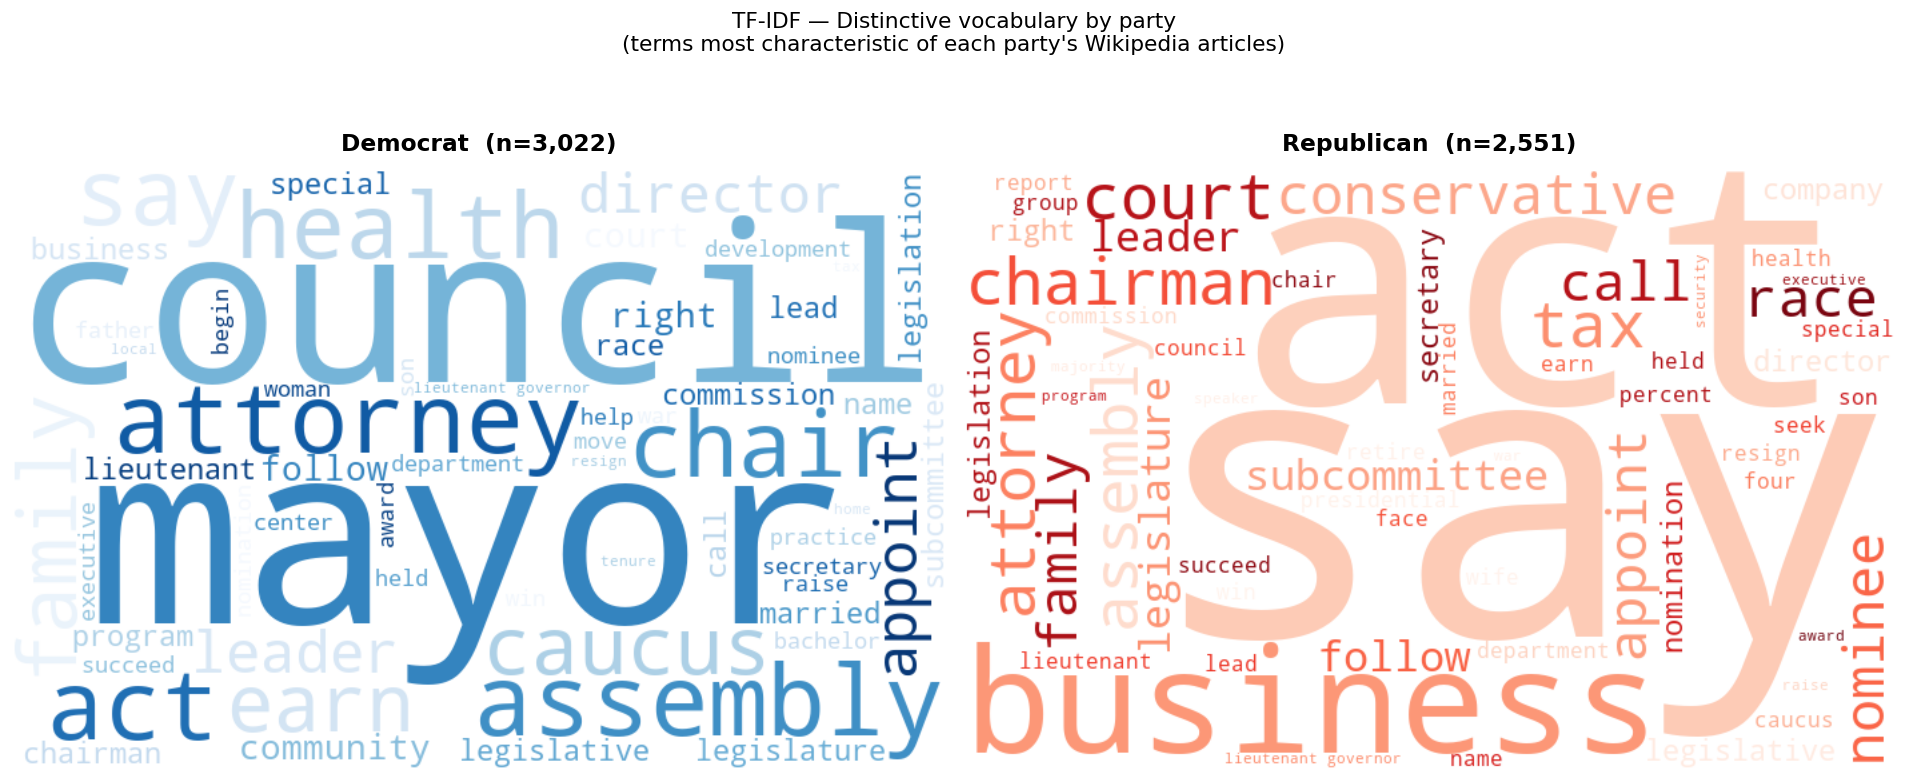

Saved → tfidf_party.png


In [5]:
def get_group_top_terms(df_subset, X_full, df_full, feat_names, top_n=80):
    """
    Average TF-IDF scores across all docs in a group.
    Returns {term: score} for top_n terms.
    """
    idx = df_full.index.get_indexer(df_subset.index)
    idx = idx[idx >= 0]
    if len(idx) == 0:
        return {}
    group_mean = X_full[idx].mean(axis=0).A1
    top_idx    = group_mean.argsort()[::-1][:top_n]
    return {feat_names[i]: float(group_mean[i]) for i in top_idx}

PARTY_STYLES = {
    "Democrat":   ("Blues",  "#2166ac"),
    "Republican": ("Reds",   "#d6604d"),
}

party_terms = {}
for party in ["Democrat", "Republican"]:
    subset = df_valid[df_valid["party"] == party]
    party_terms[party] = get_group_top_terms(
        subset, X, df_valid, feat_names, top_n=80)

    top10 = list(party_terms[party].items())[:10]
    print(f"\n{party} top 10:")
    for term, score in top10:
        print(f"  {term:30s} {score:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (party, terms) in zip(axes, party_terms.items()):
    cmap, _ = PARTY_STYLES[party]
    wc = WordCloud(
        width=700, height=450,
        background_color="white",
        colormap=cmap,
        max_words=60,
        prefer_horizontal=0.85,
        min_font_size=9,
        collocations=False,
    ).generate_from_frequencies(terms)
    ax.imshow(wc, interpolation="bilinear")
    n = len(df_valid[df_valid["party"] == party])
    ax.set_title(f"{party}  (n={n:,})", fontsize=14, fontweight="bold", pad=12)
    ax.axis("off")

plt.suptitle("TF-IDF — Distinctive vocabulary by party\n"
             "(terms most characteristic of each party's Wikipedia articles)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("tfidf_party.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tfidf_party.png")


## 5 — Community word clouds (top 9 largest)

Plotting 9 communities:
  Community  15:  782 politicians
  Community   2:  650 politicians
  Community   5:  620 politicians
  Community  30:  357 politicians
  Community   6:  254 politicians
  Community   7:  244 politicians
  Community  22:  242 politicians
  Community  16:  176 politicians
  Community  19:  175 politicians


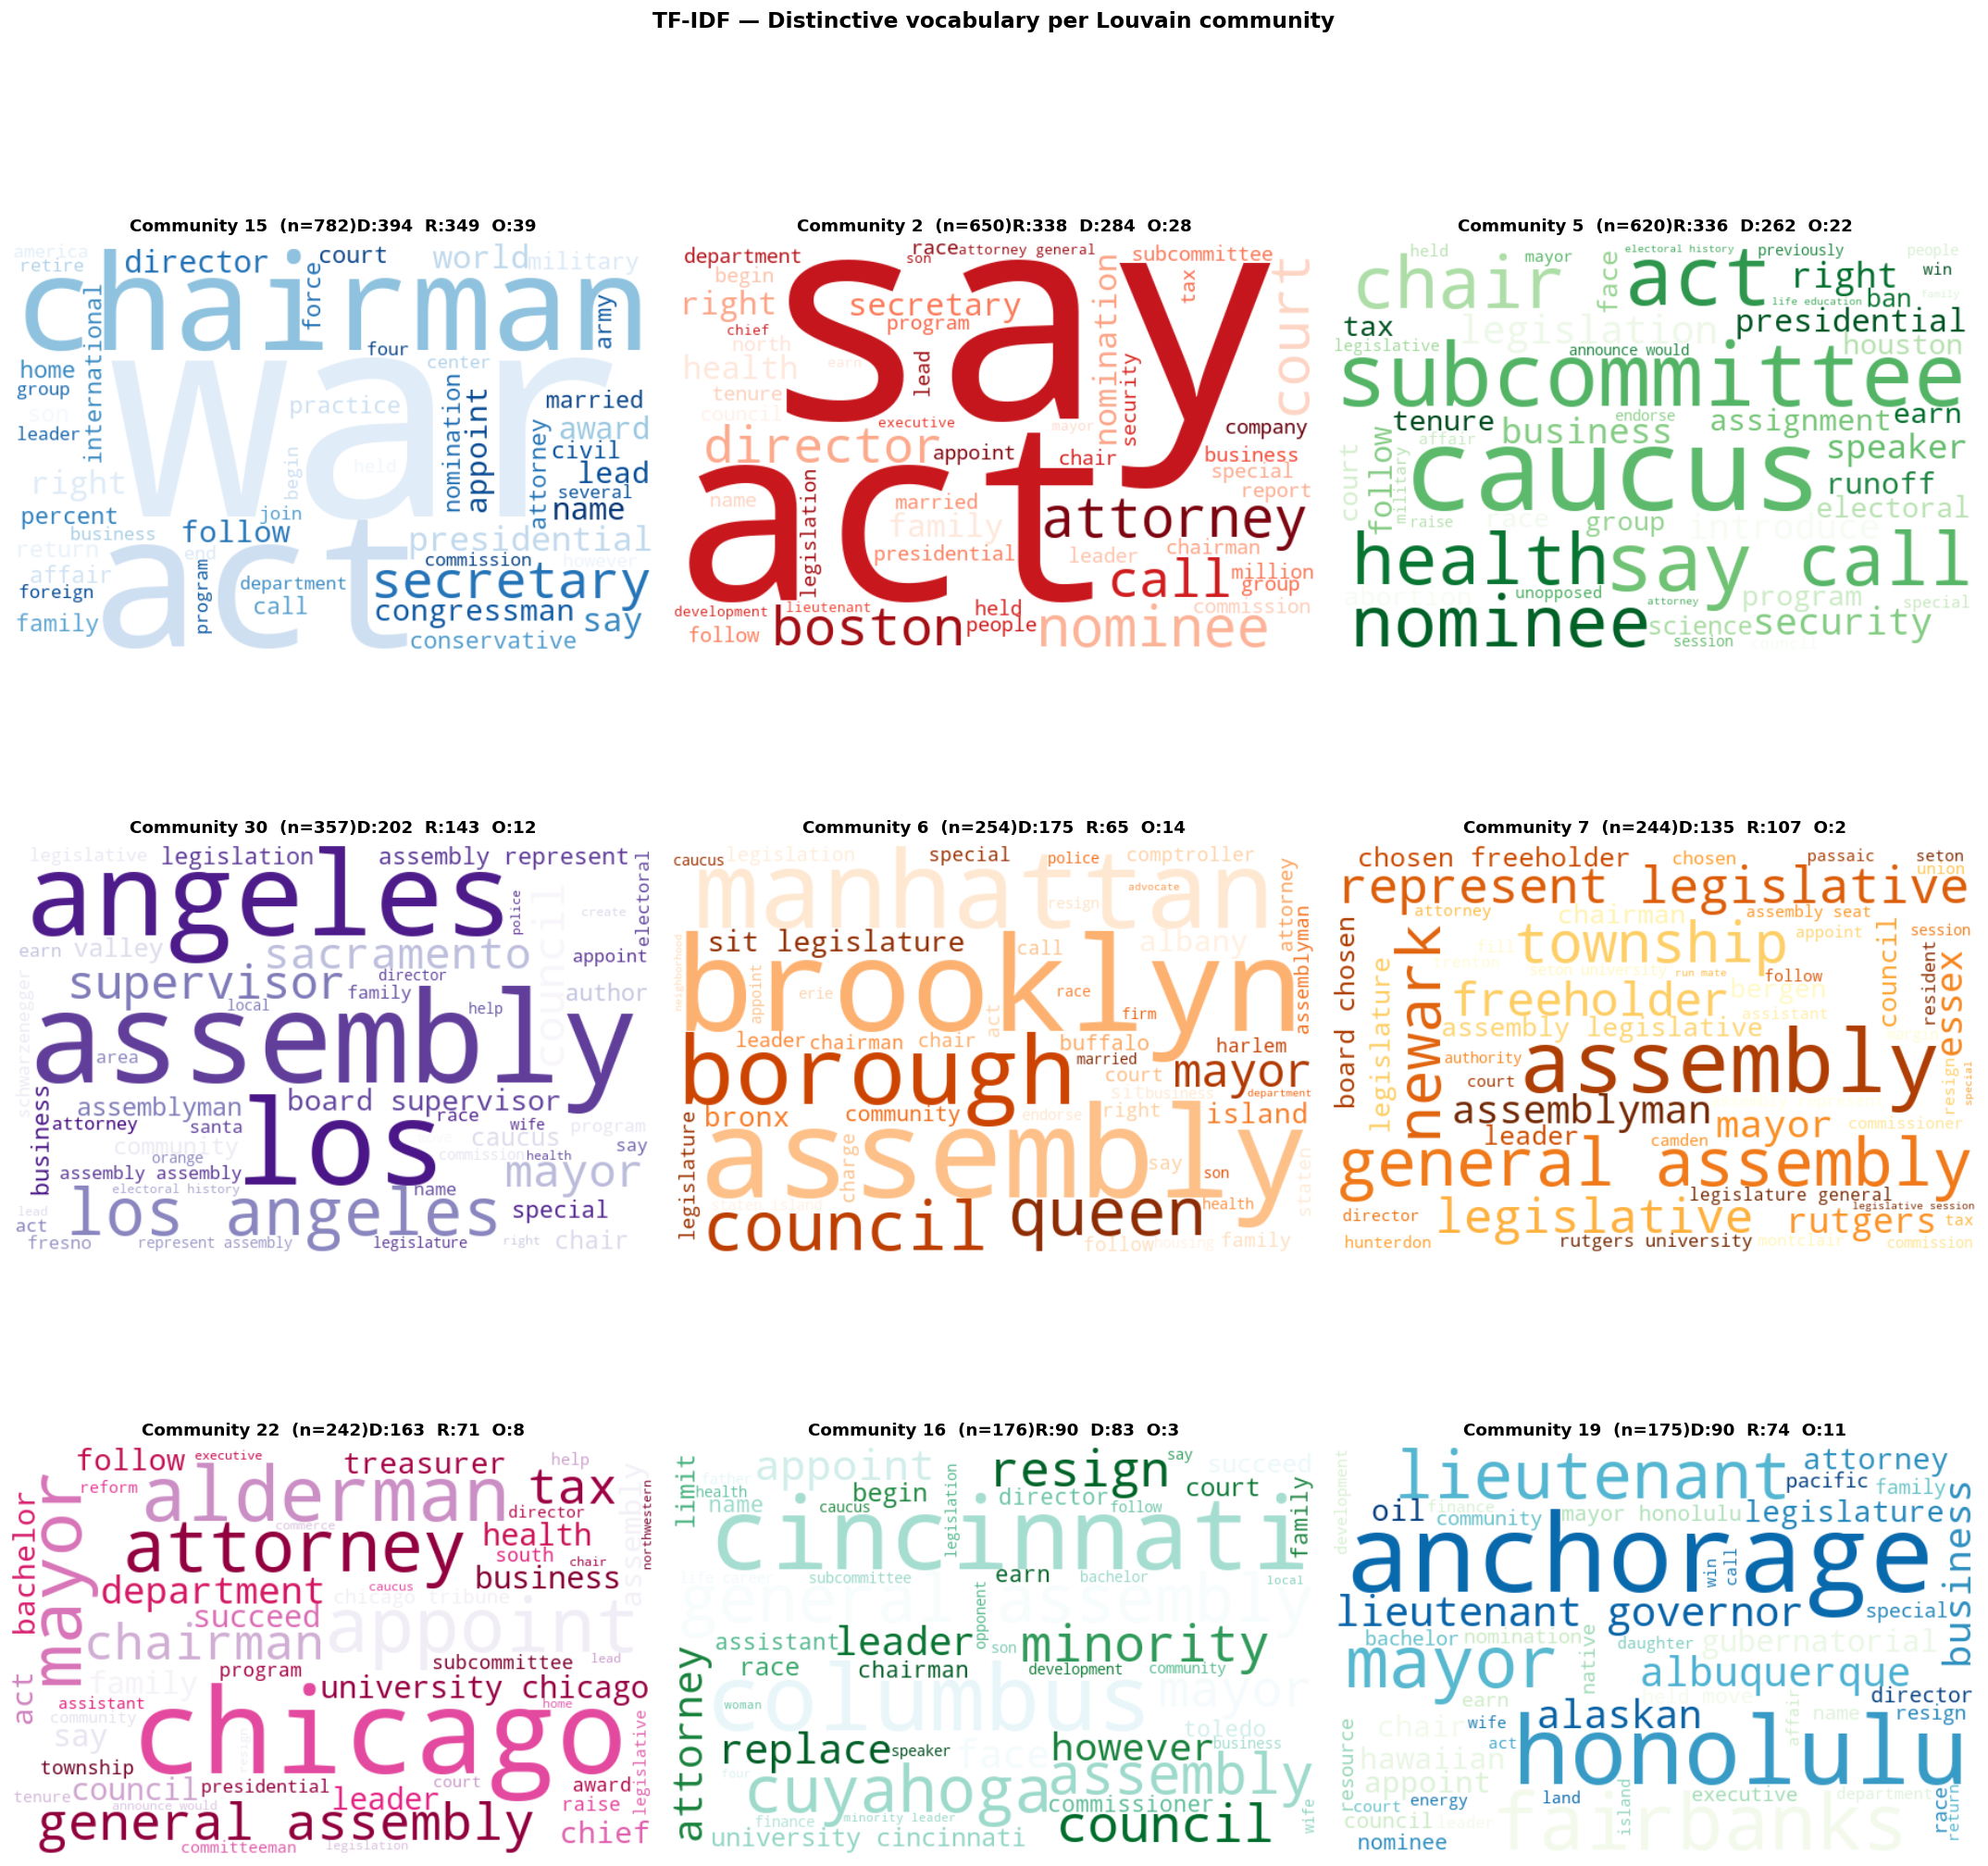

Saved → tfidf_communities.png


In [7]:
community_sizes = df_valid["community"].value_counts()
top_communities = community_sizes[community_sizes >= 50].head(9).index.tolist()

print(f"Plotting {len(top_communities)} communities:")
for c in top_communities:
    print(f"  Community {int(c):3d}: {community_sizes[c]:4d} politicians")

comm_terms = {}
for cid in top_communities:
    subset = df_valid[df_valid["community"] == cid]
    comm_terms[cid] = get_group_top_terms(
        subset, X, df_valid, feat_names, top_n=80)

cmaps = ["Blues","Reds","Greens","Purples","Oranges",
         "YlOrBr","PuRd","BuGn","GnBu"]

n_cols = 3
n_rows = (len(top_communities) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(18, 6 * n_rows), facecolor="white")
axes = axes.flat

for ax, cid, cmap in zip(axes, top_communities, cmaps):
    terms = comm_terms[cid]
    if not terms:
        ax.axis("off")
        continue
    wc = WordCloud(
        width=600, height=380,
        background_color="white",
        colormap=cmap,
        max_words=50,
        prefer_horizontal=0.85,
        min_font_size=9,
        collocations=False,
    ).generate_from_frequencies(terms)
    ax.imshow(wc, interpolation="bilinear")
    n = community_sizes[cid]

    # Add party composition as subtitle
    party_comp = df_valid[df_valid["community"]==cid]["party"].value_counts()
    party_str  = "  ".join([f"{p[0]}:{v}" for p, v in
                             party_comp.items() if p in ["Democrat","Republican","Other"]])
    ax.set_title(f"Community {int(cid)}  (n={n}){party_str}",
                 fontsize=11, fontweight="bold", pad=8)
    ax.axis("off")

# Hide unused axes
for ax in list(axes)[len(top_communities):]:
    ax.axis("off")

plt.suptitle("TF-IDF — Distinctive vocabulary per Louvain community",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tfidf_communities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tfidf_communities.png")
